In [1]:
import pandas as pd

In [2]:
import matplotlib.pyplot as plt

In [3]:
df_demo = pd.DataFrame({
    "category": ["A", "B", "C", "D", "E", "F"],
    "value": [120, 65, 75, 50, 30, 15]
})

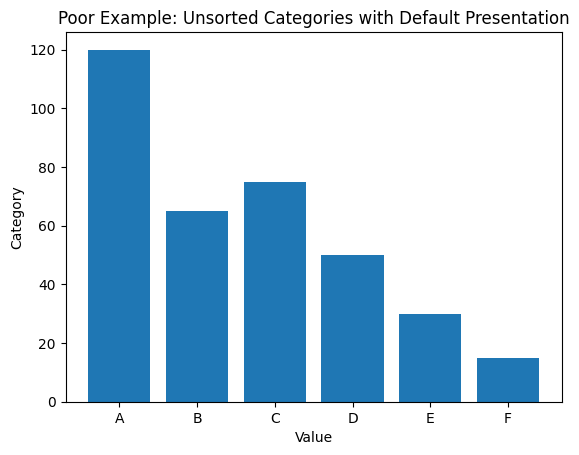

In [9]:
#Վատ վիզուալիզացիա
plt.Figure()
plt.bar(df_demo["category"], df_demo["value"])
plt.title("Poor Example: Unsorted Categories with Default Presentation")
plt.ylabel("Category")
plt.xlabel("Value")
plt.show()

In [10]:
import numpy as np

np.random.seed(42)
df_distribution = pd.DataFrame({
    "income": np.random.normal(50000, 12000, 500)
})

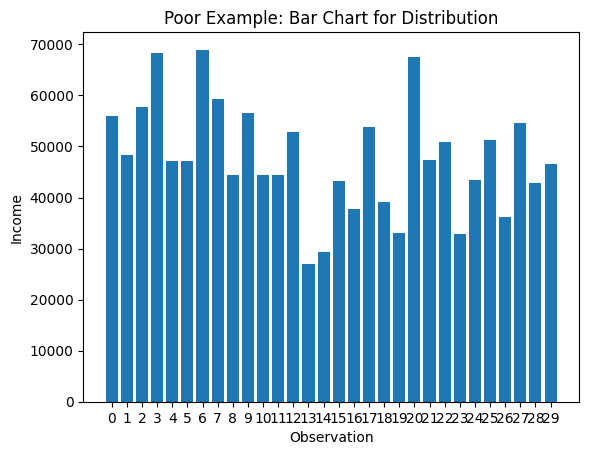

In [11]:
#Վատ պատկերացում 
sample_vals = df_distribution["income"].head(30).reset_index(drop=True)

plt.figure()
plt.bar(sample_vals.index.astype(str), sample_vals.values)
plt.title("Poor Example: Bar Chart for Distribution")
plt.xlabel("Observation")
plt.ylabel("Income")
plt.show()

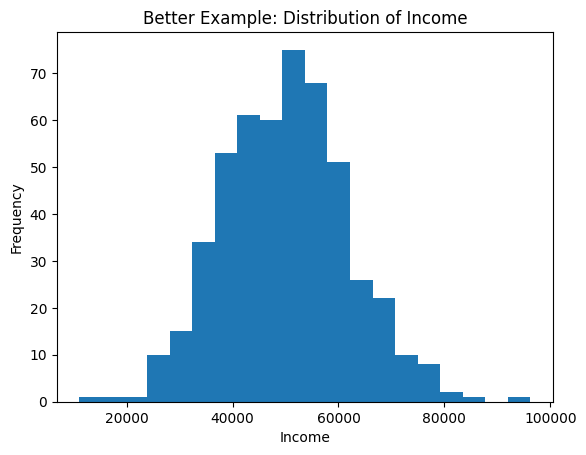

In [12]:
#Լավ վիզուալիզացիա
plt.figure()
plt.hist(df_distribution["income"], bins=20)
plt.title("Better Example: Distribution of Income")
plt.xlabel("Income")
plt.ylabel("Frequency")
plt.show()

In [13]:
np.random.seed(42)
x = np.random.normal(10, 2, 100)
y = x * 3 + np.random.normal(0, 3, 100)

df_relationship = pd.DataFrame({
    "x": x,
    "y": y
})

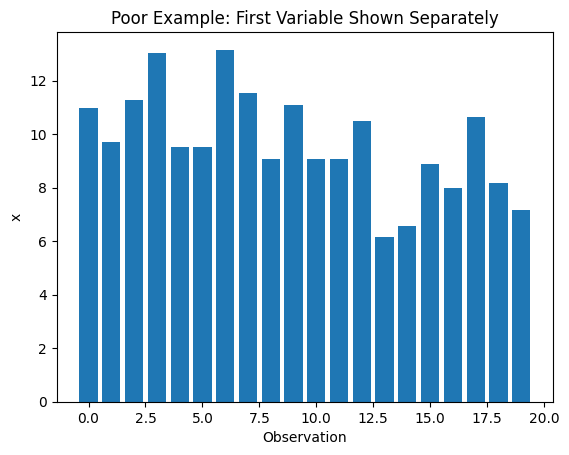

In [14]:
plt.figure()
plt.bar(range(len(df_relationship["x"].head(20))), df_relationship["x"].head(20))
plt.title("Poor Example: First Variable Shown Separately")
plt.xlabel("Observation")
plt.ylabel("x")
plt.show()

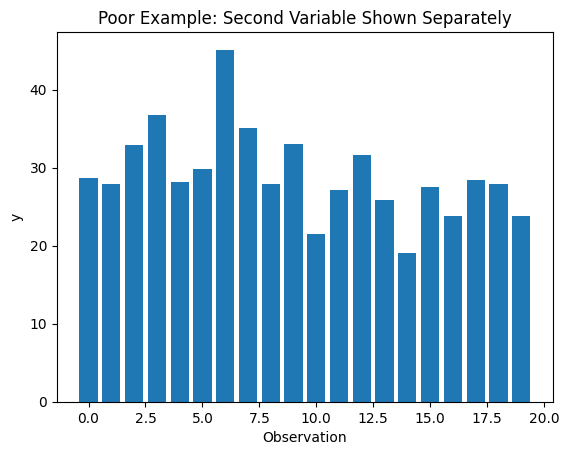

In [15]:
plt.figure()
plt.bar(range(len(df_relationship["y"].head(20))), df_relationship["y"].head(20))
plt.title("Poor Example: Second Variable Shown Separately")
plt.xlabel("Observation")
plt.ylabel("y")
plt.show()

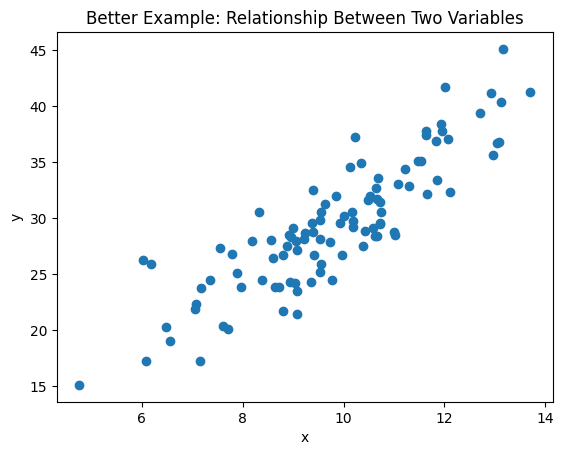

In [16]:
plt.figure()
plt.scatter(df_relationship["x"], df_relationship["y"])
plt.title("Better Example: Relationship Between Two Variables")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

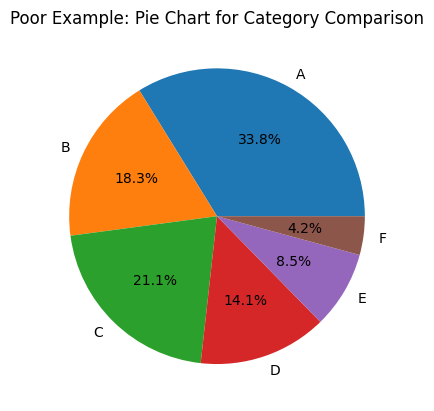

In [ ]:
#Pie chart bad
plt.figure()
plt.pie(df_demo["value"], labels=df_demo["category"], autopct="%1.1f%%")
plt.title("Poor Example: Pie Chart for Category Comparison")
plt.show()

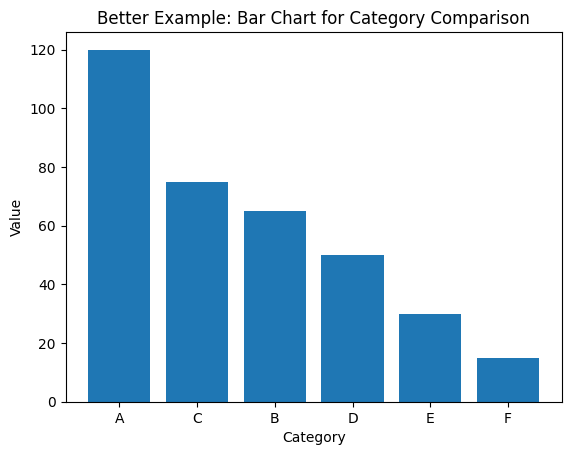

In [18]:
#Better visualization (bar chart)
df_demo_sorted = df_demo.sort_values("value", ascending=False)

plt.figure()
plt.bar(df_demo_sorted["category"], df_demo_sorted["value"])
plt.title("Better Example: Bar Chart for Category Comparison")
plt.xlabel("Category")
plt.ylabel("Value")
plt.show()

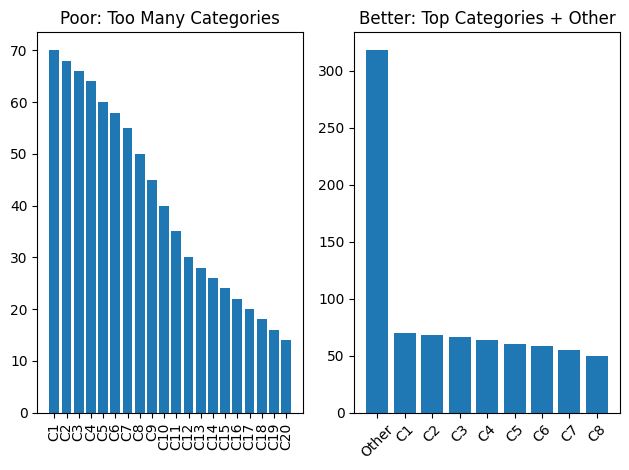

In [19]:
categories = [f"C{i}" for i in range(1, 21)]
values = [70, 68, 66, 64, 60, 58, 55, 50, 45, 40, 35, 30, 28, 26, 24, 22, 20, 18, 16, 14]
df_many = pd.DataFrame({"category": categories, "value": values})

top8 = df_many.nlargest(8, "value").copy()
other_sum = df_many.nsmallest(len(df_many) - 8, "value")["value"].sum()
df_top_other = pd.concat(
    [top8, pd.DataFrame([{"category": "Other", "value": other_sum}])],
    ignore_index=True
)
df_top_other = df_top_other.sort_values("value", ascending=False)

fig, ax = plt.subplots(1, 2)
ax[0].bar(df_many["category"], df_many["value"])
ax[0].set_title("Poor: Too Many Categories")
ax[0].tick_params(axis="x", rotation=90)
ax[1].bar(df_top_other["category"], df_top_other["value"])
ax[1].set_title("Better: Top Categories + Other")
ax[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

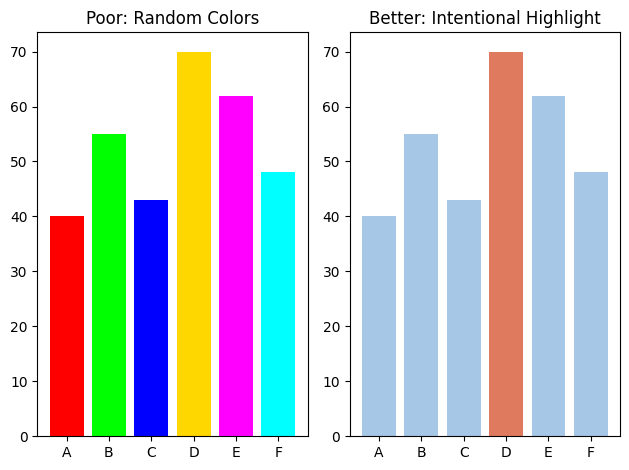

In [20]:
df_color = pd.DataFrame({
    "group": ["A", "B", "C", "D", "E", "F"],
    "value": [40, 55, 43, 70, 62, 48]
})

random_colors = ["red", "lime", "blue", "gold", "magenta", "cyan"]
focus_colors = ["#A7C7E7", "#A7C7E7", "#A7C7E7", "#E07A5F", "#A7C7E7", "#A7C7E7"]

fig, ax = plt.subplots(1, 2)
ax[0].bar(df_color["group"], df_color["value"], color=random_colors)
ax[0].set_title("Poor: Random Colors")
ax[1].bar(df_color["group"], df_color["value"], color=focus_colors)
ax[1].set_title("Better: Intentional Highlight")
plt.tight_layout()
plt.show()

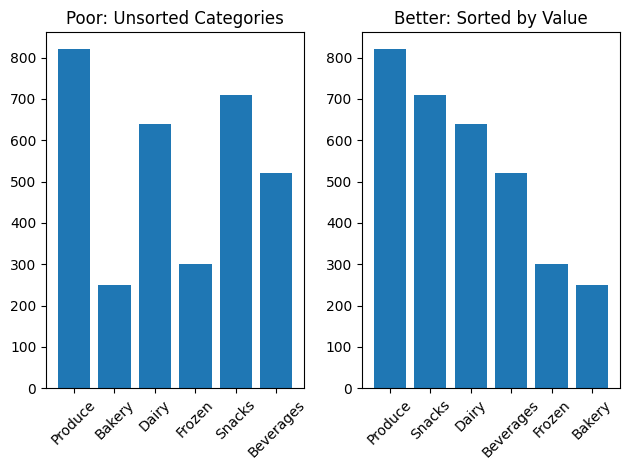

In [21]:
df_rank = pd.DataFrame({
    "department": ["Produce", "Bakery", "Dairy", "Frozen", "Snacks", "Beverages"],
    "orders": [820, 250, 640, 300, 710, 520]
})

fig, ax = plt.subplots(1, 2)
ax[0].bar(df_rank["department"], df_rank["orders"])
ax[0].set_title("Poor: Unsorted Categories")
ax[0].tick_params(axis="x", rotation=45)
df_rank_sorted = df_rank.sort_values("orders", ascending=False)
ax[1].bar(df_rank_sorted["department"], df_rank_sorted["orders"])
ax[1].set_title("Better: Sorted by Value")
ax[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

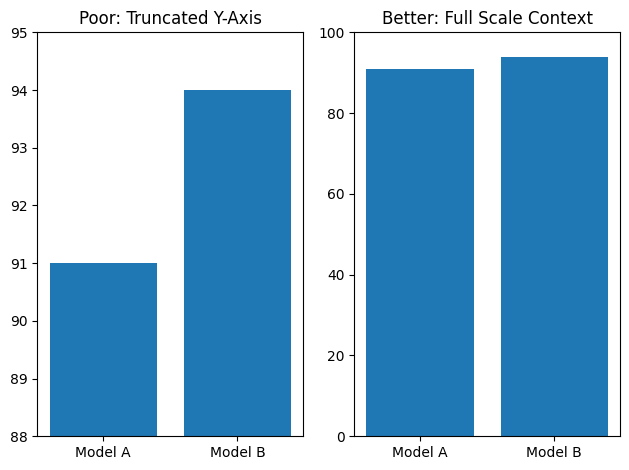

In [22]:
df_axis = pd.DataFrame({
    "model": ["Model A", "Model B"],
    "accuracy": [91, 94]
})

fig, ax = plt.subplots(1, 2)
ax[0].bar(df_axis["model"], df_axis["accuracy"])
ax[0].set_ylim(88, 95)
ax[0].set_title("Poor: Truncated Y-Axis")
ax[1].bar(df_axis["model"], df_axis["accuracy"])
ax[1].set_ylim(0, 100)
ax[1].set_title("Better: Full Scale Context")
plt.tight_layout()
plt.show()

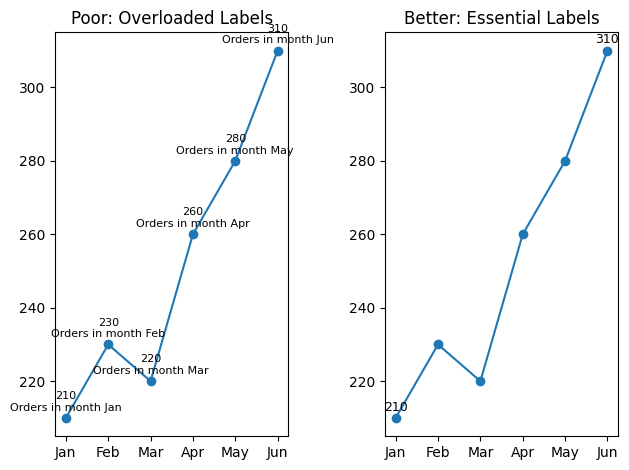

In [28]:
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun"]
orders = [210, 230, 220, 260, 280, 310]

fig, ax = plt.subplots(1, 2)
ax[0].plot(months, orders, marker="o")
for i, val in enumerate(orders):
    ax[0].text(i, val + 2, f"{val}\nOrders in month {months[i]}", ha="center", fontsize=8)
ax[0].set_title("Poor: Overloaded Labels")
ax[1].plot(months, orders, marker="o")
for i, val in enumerate(orders):
    if i in [0, len(orders) - 1]:
        ax[1].text(i, val + 2, str(val), ha="center", fontsize=9)
ax[1].set_title("Better: Essential Labels")
plt.tight_layout()
plt.show()

In [24]:
df = pd.read_csv("https://raw.githubusercontent.com/hovhannisyan91/data_analytics_with_python/refs/heads/main/data/dummy_data.csv")
# Preview the data
df.head()

,customer_id,age,region,segment,income,monthly_spend
0,1,56,West,Medium Value,63353.0,2411.0
1,2,69,East,Medium Value,64900.0,2688.0
2,3,46,East,Low Value,47074.0,1147.0
3,4,32,North,High Value,30267.0,1671.0
4,5,60,North,High Value,44233.0,2753.0


In [29]:
import plotly.express as px

fig = px.scatter(
    data_frame=df, # data
    x="age", # x aesthetic
    y="income", # y aesthetic
    color="segment", # color aesthetic
    size="monthly_spend", # size aesthetic
    facet_col="region", # facet
    trendline="ols", # statistical layer
    title="Relationship Between Customer Age and Income"
)

fig.show()

ModuleNotFoundError: No module named 'statsmodels'

In [30]:
sales_by_region = (
    df
    .groupby("region", as_index=False)
    .agg(
        total_sales=("monthly_spend", "sum"),
        avg_sales=("monthly_spend", "mean"),
        number_of_customers=("customer_id", "count")
    )
)

In [31]:
fig = px.bar(
    data_frame=sales_by_region,
    x="region",
    y="total_sales",
    title="Total Sales by Region"
)

fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

In [32]:
daily_sales = (
    df
    .assign(
        date=pd.date_range(
            start="2026-01-01",
            periods=len(df),
            freq="D"
        )
    )
    .groupby("date", as_index=False)
    .agg(
        sales=("monthly_spend", "sum"),
        number_of_customers=("customer_id", "count"),
        avg_sales=("monthly_spend", "mean")
    )
)

# Round values for cleaner display
daily_sales["sales"] = daily_sales["sales"].round(0)
daily_sales["avg_sales"] = daily_sales["avg_sales"].round(2)

daily_sales.head()

,date,sales,number_of_customers,avg_sales
0,2026-01-01,2411.0,1,2411.0
1,2026-01-02,2688.0,1,2688.0
2,2026-01-03,1147.0,1,1147.0
3,2026-01-04,1671.0,1,1671.0
4,2026-01-05,2753.0,1,2753.0


In [35]:
fig = px.line(
    data_frame=daily_sales,
    x="date",
    y="sales",
    title="Sales Trend Over Time"
)

fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

In [36]:
df_instacart = pd.read_parquet("../data/processed/instacart.parquet")
df_instacart.head()

,order_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,add_to_cart_order,reordered,product_name,prices,department,...,Surname,Gender,state,Age,date_joined,n_dependants,fam_status,income,region,division
0,1187899,11,4,8,14.0,1,1,Soda,9.0,beverages,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central
1,1187899,11,4,8,14.0,2,1,Organic String Cheese,8.6,dairy eggs,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central
2,1187899,11,4,8,14.0,3,1,0% Greek Strained Yogurt,12.6,dairy eggs,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central
3,1187899,11,4,8,14.0,4,1,XL Pick-A-Size Paper Towel Rolls,1.0,household,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central
4,1187899,11,4,8,14.0,5,1,Milk Chocolate Almonds,6.8,snacks,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central


In [38]:
df_instacart.shape

(1384706, 22)

In [39]:
df_instacart.columns

Index(['order_id', 'order_number', 'order_dow', 'order_hour_of_day',
       'days_since_prior_order', 'add_to_cart_order', 'reordered',
       'product_name', 'prices', 'department', 'aisle', 'First Name',
       'Surname', 'Gender', 'state', 'Age', 'date_joined', 'n_dependants',
       'fam_status', 'income', 'region', 'division'],
      dtype='str')

In [40]:
df_instacart.head()

,order_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,add_to_cart_order,reordered,product_name,prices,department,...,Surname,Gender,state,Age,date_joined,n_dependants,fam_status,income,region,division
0,1187899,11,4,8,14.0,1,1,Soda,9.0,beverages,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central
1,1187899,11,4,8,14.0,2,1,Organic String Cheese,8.6,dairy eggs,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central
2,1187899,11,4,8,14.0,3,1,0% Greek Strained Yogurt,12.6,dairy eggs,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central
3,1187899,11,4,8,14.0,4,1,XL Pick-A-Size Paper Towel Rolls,1.0,household,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central
4,1187899,11,4,8,14.0,5,1,Milk Chocolate Almonds,6.8,snacks,...,Nguyen,Female,Alabama,31,2/17/2019,3,married,40423,South,East South Central


In [43]:
orders_by_day = (
    df_instacart[["order_id", "order_dow"]]
    .drop_duplicates()
    .groupby("order_dow")
    .size()
)

orders_by_day

order_dow
0    27465
1    19672
2    16119
3    15687
4    15959
5    17406
6    18901
dtype: int64

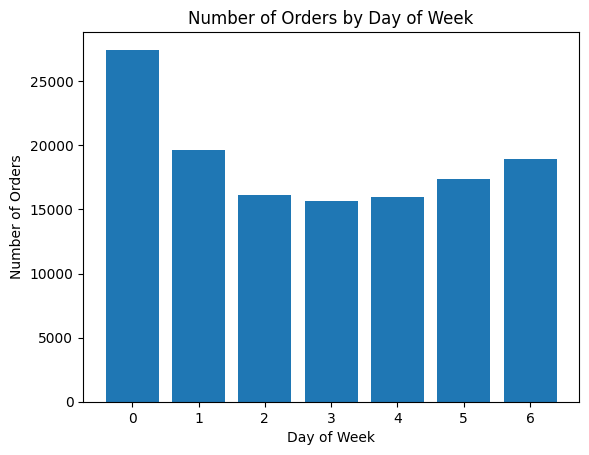

In [44]:
orders_by_day = (
    df_instacart[["order_id", "order_dow"]]
    .drop_duplicates()
    .groupby("order_dow")
    .size()
)

plt.figure()
plt.bar(orders_by_day.index, orders_by_day.values)
plt.title("Number of Orders by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Orders")
plt.show()

In [45]:
orders_by_hour = (
    df_instacart[["order_id", "order_hour_of_day"]]
    .drop_duplicates()
    .groupby("order_hour_of_day")
    .size()
)

orders_by_hour.head()

order_hour_of_day
0    852
1    507
2    305
3    223
4    218
dtype: int64

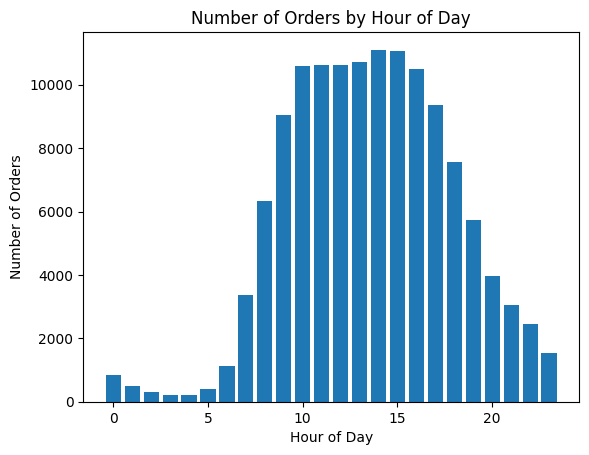

In [46]:
orders_by_hour = (
    df_instacart[["order_id", "order_hour_of_day"]]
    .drop_duplicates()
    .groupby("order_hour_of_day")
    .size()
)

plt.figure()
plt.bar(orders_by_hour.index, orders_by_hour.values)
plt.title("Number of Orders by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Orders")
plt.show()

In [47]:
top_departments = df_instacart["department"].value_counts().head(10)
top_departments

department
produce            409087
dairy eggs         217051
snacks             118862
beverages          113962
frozen             100426
pantry              81242
bakery              48394
canned goods        46799
deli                44291
dry goods pasta     38713
Name: count, dtype: int64

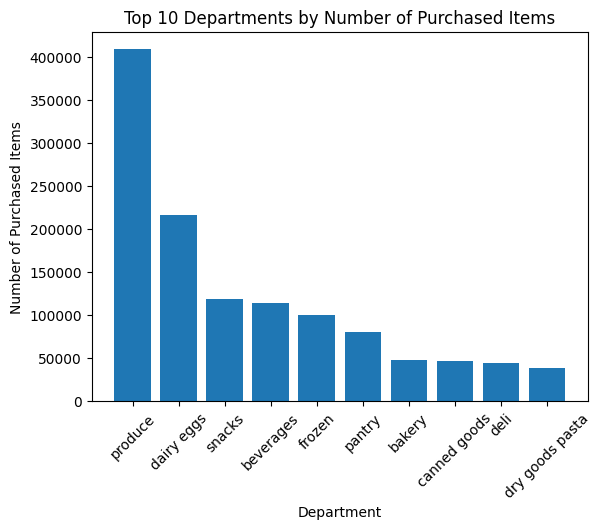

In [48]:
top_departments = df_instacart["department"].value_counts().head(10)

plt.figure()
plt.bar(top_departments.index, top_departments.values)
plt.title("Top 10 Departments by Number of Purchased Items")
plt.xlabel("Department")
plt.ylabel("Number of Purchased Items")
plt.xticks(rotation=45)
plt.show()

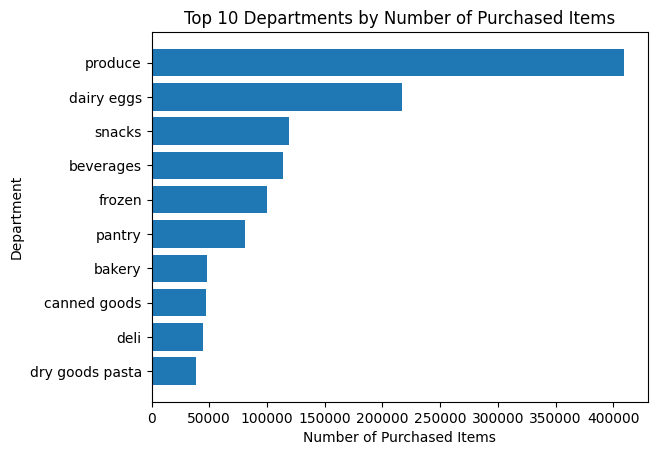

In [49]:
top_departments_sorted = df_instacart["department"].value_counts().head(10).sort_values()

plt.figure()
plt.barh(top_departments_sorted.index, top_departments_sorted.values)
plt.title("Top 10 Departments by Number of Purchased Items")
plt.xlabel("Number of Purchased Items")
plt.ylabel("Department")
plt.show()

In [50]:
df_instacart["prices"].describe()

count    1.384618e+06
mean     1.411711e+01
std      6.802253e+02
min      1.000000e+00
25%      4.300000e+00
50%      7.400000e+00
75%      1.130000e+01
max      9.999900e+04
Name: prices, dtype: float64

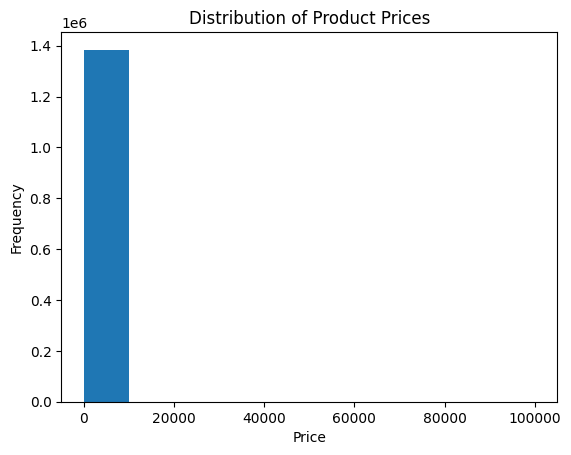

In [51]:
plt.figure()
plt.hist(df_instacart["prices"].dropna(), bins=10)
plt.title("Distribution of Product Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

In [52]:
upper_limit = df_instacart["prices"].quantile(0.99)
upper_limit

np.float64(18.1)

In [53]:
df_prices_q = df_instacart[df_instacart["prices"] <= upper_limit]
df_prices_q["prices"].describe()

count    1.370887e+06
mean     7.668451e+00
std      4.039330e+00
min      1.000000e+00
25%      4.200000e+00
50%      7.300000e+00
75%      1.120000e+01
max      1.810000e+01
Name: prices, dtype: float64

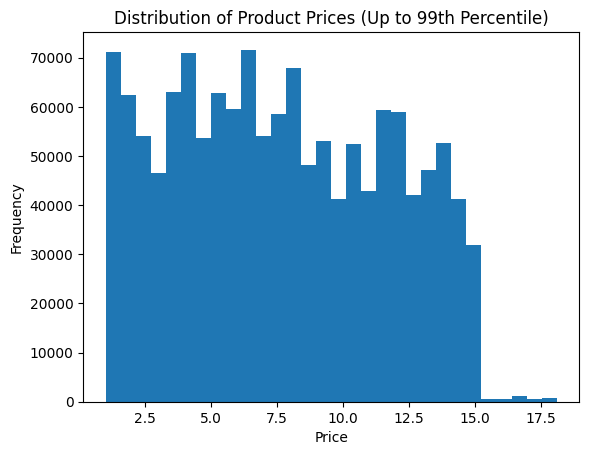

In [54]:
plt.figure()
plt.hist(df_prices_q["prices"].dropna(), bins=30)
plt.title("Distribution of Product Prices (Up to 99th Percentile)")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

In [55]:
upper_limit_95 = df_instacart["prices"].quantile(0.95)
upper_limit_95

np.float64(14.3)

In [56]:
df_prices_q95 = df_instacart[df_instacart["prices"] <= upper_limit_95]
df_prices_q95["prices"].describe()

count    1.316686e+06
mean     7.373599e+00
std      3.843880e+00
min      1.000000e+00
25%      4.100000e+00
50%      7.100000e+00
75%      1.060000e+01
max      1.430000e+01
Name: prices, dtype: float64

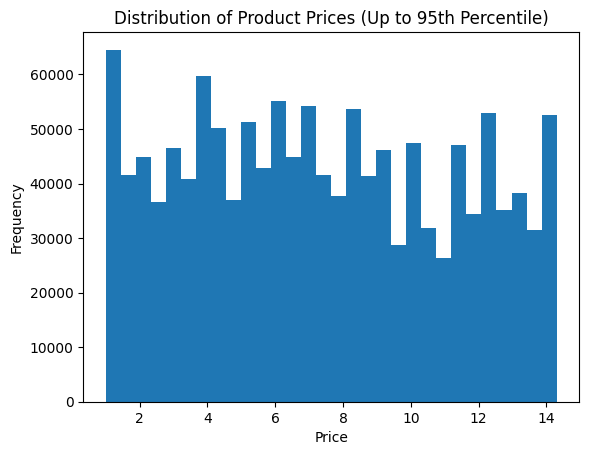

In [57]:
plt.figure()
plt.hist(df_prices_q95["prices"].dropna(), bins=30)
plt.title("Distribution of Product Prices (Up to 95th Percentile)")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

In [58]:
avg_price_by_department = (
    df_instacart
    .groupby("department")["prices"]
    .mean()
    .sort_values(ascending=True)
)

avg_price_by_department

department
snacks              4.272277
other               7.184457
dry goods pasta     7.388252
household           7.402065
canned goods        7.530263
beverages           7.660526
babies              7.682672
deli                7.768707
international       7.799126
frozen              7.801781
bakery              7.833023
pets                7.867823
pantry              7.955316
personal care       7.989259
produce             7.997862
breakfast           8.090261
alcohol             8.126044
bulk                8.211626
missing             8.599139
meat seafood       16.202349
dairy eggs         48.606962
Name: prices, dtype: float64

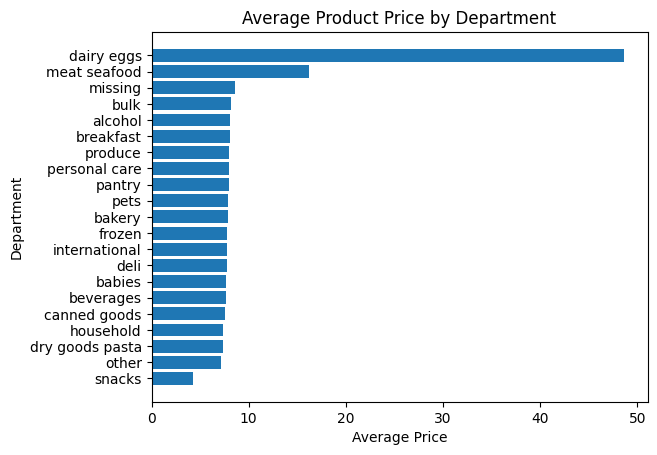

In [59]:
avg_price_by_department = (
    df_instacart
    .groupby("department")["prices"]
    .mean()
    .sort_values(ascending=True)
)

plt.figure()
plt.barh(avg_price_by_department.index, avg_price_by_department.values)
plt.title("Average Product Price by Department")
plt.xlabel("Average Price")
plt.ylabel("Department")
plt.show()

In [60]:
customer_profile = df_instacart[
    ["First Name", "Surname", "Age", "income"]
].drop_duplicates()

customer_profile.head()

,First Name,Surname,Age,income
0,Linda,Nguyen,31,40423
11,Norma,Chapman,68,64940
42,Janet,Lester,75,115242
51,Peter,Villegas,39,89095
60,Anna,Allison,32,88603


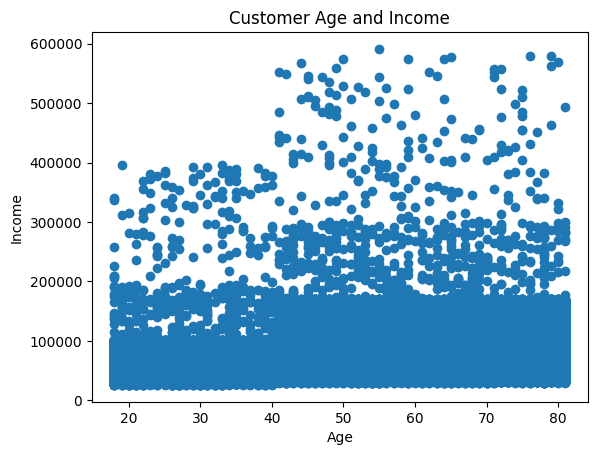

In [61]:
customer_profile = df_instacart[
    ["First Name", "Surname", "Age", "income"]
].drop_duplicates()

plt.figure()
plt.scatter(customer_profile["Age"], customer_profile["income"])
plt.title("Customer Age and Income")
plt.xlabel("Age")
plt.ylabel("Income")
plt.show()